**M2 - Análise Exploratória de Dados - Gustavo Lobato Campos e Rafael Vinicius Tayette da Nobrega**

**Fonte dos dados:** [Kaggle - Solar Power Generation Data (anikannal)](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)

Data de acesso: 02/07/2026

Este notebook implementa a análise exploratória de dados (EDA) de duas usinas solares fotovoltaicas (Planta 1 e Planta 2), cada uma com dois arquivos: dados de geração dos inversores (`Generation_Data.csv`) e dados do sensor meteorológico (`Weather_Sensor_Data.csv`).

Estrutura do notebook: 
1. Configuração inicial 
2. Planta 1: contexto, qualidade, distribuições e relações
3. Planta 2: contexto, qualidade, distribuições e relações
4. Comparação entre as Plantas 1 e 2


**1. Configuração inicial:** 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid", palette = "viridis")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_STATE = 42
TARGET = 'AC_POWER'   # variável alvo: potência AC gerada pelo inversor (kW)

def resumo_ausentes(df, nome):
    # Tabela de valores ausentes por coluna, com taxa (%) e decisão sugerida
    n = len(df)
    tab = pd.DataFrame({
        'coluna': df.columns,
        'n_ausentes': df.isna().sum().values,
    })
    tab['taxa_%'] = (tab['n_ausentes'] / n * 100).round(3)
    def decisao(taxa):
        if taxa == 0:
            return 'Manter (sem ausentes)'
        elif taxa < 5:
            return 'Imputar (interpolação temporal)'
        elif taxa < 30:
            return 'Avaliar imputação por série temporal/vizinhos'
        else:
            return 'Considerar remoção da coluna'
    tab['decisão'] = tab['taxa_%'].apply(decisao)
    tab.insert(0, 'dataset', nome)
    return tab.reset_index(drop = True)

def resumo_contexto(df, nome, dt_col = 'DATE_TIME'):
    print(f"--- {nome} ---")
    print(f"Nº de registros : {len(df):,}".replace(',', '.'))
    print(f"Nº de variáveis : {df.shape[1]}")
    print(f"Variáveis       : {list(df.columns)}")
    print(f"Período         : {df[dt_col].min()} até {df[dt_col].max()}")
    print()


**2. Planta 1:**

2.1 Contexto: 

Arquivos utilizados: `Plant_1_Generation_Data.csv` (dados de geração por inversor, granularidade de 15 min) e `Plant_1_Weather_Sensor_Data.csv` (dados do sensor meteorológico da Planta 1).

Data de acesso: 02/07/2026

Período coberto: 15/05/2020 a 17/06/2020 (aproximadamente 34 dias)

In [35]:
# Carregamento dos dados da Planta 1
gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
wth1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

# Padronização das datas dos dois arquivo
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], format='%d-%m-%Y %H:%M')
wth1['DATE_TIME'] = pd.to_datetime(wth1['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

resumo_contexto(gen1, 'Plant_1_Generation_Data.csv')
resumo_contexto(wth1, 'Plant_1_Weather_Sensor_Data.csv')

print(f"Nº de inversores (SOURCE_KEY) na Planta 1: {gen1['SOURCE_KEY'].nunique()}")


--- Plant_1_Generation_Data.csv ---
Nº de registros : 68.778
Nº de variáveis : 7
Variáveis       : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
Período         : 2020-05-15 00:00:00 até 2020-06-17 23:45:00

--- Plant_1_Weather_Sensor_Data.csv ---
Nº de registros : 3.182
Nº de variáveis : 6
Variáveis       : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
Período         : 2020-05-15 00:00:00 até 2020-06-17 23:45:00

Nº de inversores (SOURCE_KEY) na Planta 1: 22


In [36]:
# Merge dos dados de geração + clima pela data/hora e planta, formando o dataframe da Planta 1
df1 = pd.merge(gen1, wth1.drop(columns = ['SOURCE_KEY']), on = ['DATE_TIME', 'PLANT_ID'], how = 'left')
print(f"Base combinada Planta 1: {df1.shape[0]:,} registros x {df1.shape[1]} colunas".replace(',', '.'))
df1.head()


Base combinada Planta 1: 68.778 registros x 10 colunas


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0


2.1.1 Estatísticas descritivas da base combinada da Planta 1: 

In [37]:
desc1 = df1.describe().T
desc1


,count,mean,min,25%,50%,75%,max,std
DATE_TIME,68778,2020-06-01 08:02:49.458256896,2020-05-15 00:00:00,2020-05-24 00:45:00,2020-06-01 14:30:00,2020-06-09 20:00:00,2020-06-17 23:45:00,NaN
PLANT_ID,68778.0,4135001.0,4135001.0,4135001.0,4135001.0,4135001.0,4135001.0,0.0
DC_POWER,68778.0,3147.426211,0.0,0.0,429.0,6366.964286,14471.125,4036.457169
AC_POWER,68778.0,307.802752,0.0,0.0,41.49375,623.61875,1410.95,394.396439
DAILY_YIELD,68778.0,3295.968737,0.0,0.0,2658.714286,6274.0,9163.0,3145.178309
TOTAL_YIELD,68778.0,6978711.760671,6183645.0,6512002.53575,7146685.0,7268705.90625,7846821.0,416271.982856
AMBIENT_TEMPERATURE,68774.0,25.558521,20.398505,22.724491,24.670178,27.960429,35.252486,3.3613
MODULE_TEMPERATURE,68774.0,31.244997,18.140415,21.123944,24.818984,41.693659,65.545714,12.308283
IRRADIATION,68774.0,0.232305,0.0,0.0,0.03162,0.45488,1.221652,0.301948


2.2 Qualidade dos dados: 

In [38]:
# Ausentes: arquivos originais + base combinada
# O merge pode gerar ausentes se algum horário do inversor não tiver leitura correspondente no sensor meteorológico
tab_ausentes_1 = pd.concat([
    resumo_ausentes(gen1, 'Plant_1_Generation_Data'),
    resumo_ausentes(wth1, 'Plant_1_Weather_Sensor_Data'),
    resumo_ausentes(df1,  'Plant_1_Combinado (merge)'),
], ignore_index = True)
tab_ausentes_1


,dataset,coluna,n_ausentes,taxa_%,decisão
0,Plant_1_Generation_Data,DATE_TIME,0,0.000,Manter (sem ausentes)
1,Plant_1_Generation_Data,PLANT_ID,0,0.000,Manter (sem ausentes)
2,Plant_1_Generation_Data,SOURCE_KEY,0,0.000,Manter (sem ausentes)
3,Plant_1_Generation_Data,DC_POWER,0,0.000,Manter (sem ausentes)
4,Plant_1_Generation_Data,AC_POWER,0,0.000,Manter (sem ausentes)
5,Plant_1_Generation_Data,DAILY_YIELD,0,0.000,Manter (sem ausentes)
6,Plant_1_Generation_Data,TOTAL_YIELD,0,0.000,Manter (sem ausentes)
7,Plant_1_Weather_Sensor_Data,DATE_TIME,0,0.000,Manter (sem ausentes)
8,Plant_1_Weather_Sensor_Data,PLANT_ID,0,0.000,Manter (sem ausentes)
9,Plant_1_Weather_Sensor_Data,SOURCE_KEY,0,0.000,Manter (sem ausentes)


In [39]:
# Duplicatas: antes e depois (linhas 100% idênticas em todas as colunas)
dup_gen1_antes = gen1.duplicated().sum()
dup_wth1_antes = wth1.duplicated().sum()

gen1_dedup = gen1.drop_duplicates()
wth1_dedup = wth1.drop_duplicates()

dup_gen1_depois = gen1_dedup.duplicated().sum()
dup_wth1_depois = wth1_dedup.duplicated().sum()

# Duplicatas: mesmo inversor (SOURCE_KEY) e mesmo DATE_TIME
dup_logica_gen1 = gen1.duplicated(subset=['DATE_TIME', 'SOURCE_KEY']).sum()

tab_dup_1 = pd.DataFrame({
    'dataset': ['Plant_1_Generation_Data', 'Plant_1_Weather_Sensor_Data'],
    'duplicatas_antes': [dup_gen1_antes, dup_wth1_antes],
    'duplicatas_depois': [dup_gen1_depois, dup_wth1_depois],
    'duplicatas_logicas_(DATE_TIME+SOURCE_KEY)': [dup_logica_gen1, np.nan],
})
tab_dup_1


,dataset,duplicatas_antes,duplicatas_depois,duplicatas_logicas_(DATE_TIME+SOURCE_KEY)
0,Plant_1_Generation_Data,0,0,0.0
1,Plant_1_Weather_Sensor_Data,0,0,NaN


In [40]:
print("Avaliação da qualidade da Planta 1:")
print(f" - Ausentes nos arquivos originais: 0 em todas as colunas -> manter, sem necessidade de imputação.")
if tab_ausentes_1.query("dataset == 'Plant_1_Combinado (merge)'")['n_ausentes'].sum() == 0:
    print(" - Após o merge geração + clima: nenhum ausente introduzido -> base combinada íntegra.")
else:
    print(" - Após o merge geração + clima: há ausentes -> avaliar imputação por interpolação temporal.")
print(f" - Duplicatas exatas: {dup_gen1_antes} (geração) e {dup_wth1_antes} (clima) -> nenhuma remoção necessária.")


Avaliação da qualidade da Planta 1:
 - Ausentes nos arquivos originais: 0 em todas as colunas -> manter, sem necessidade de imputação.
 - Após o merge geração + clima: há ausentes -> avaliar imputação por interpolação temporal.
 - Duplicatas exatas: 0 (geração) e 0 (clima) -> nenhuma remoção necessária.


Implementação da imputação por interpolação temporal na base combinada da Planta 1: interpolação linear ordenada pelo tempo, usando os pontos vizinhos:

In [41]:
cols_clima_1 = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
n_ausentes_antes_1 = df1[cols_clima_1].isna().sum().sum()

df1 = df1.sort_values('DATE_TIME')
df1[cols_clima_1] = df1[cols_clima_1].interpolate(method = 'linear', limit_direction = 'both')

n_ausentes_depois_1 = df1[cols_clima_1].isna().sum().sum()
print(f"Ausentes nas colunas climáticas antes da imputação : {n_ausentes_antes_1}")
print(f"Ausentes nas colunas climáticas depois da imputação: {n_ausentes_depois_1}")


Ausentes nas colunas climáticas antes da imputação : 12
Ausentes nas colunas climáticas depois da imputação: 0


2.3 Distribuições:

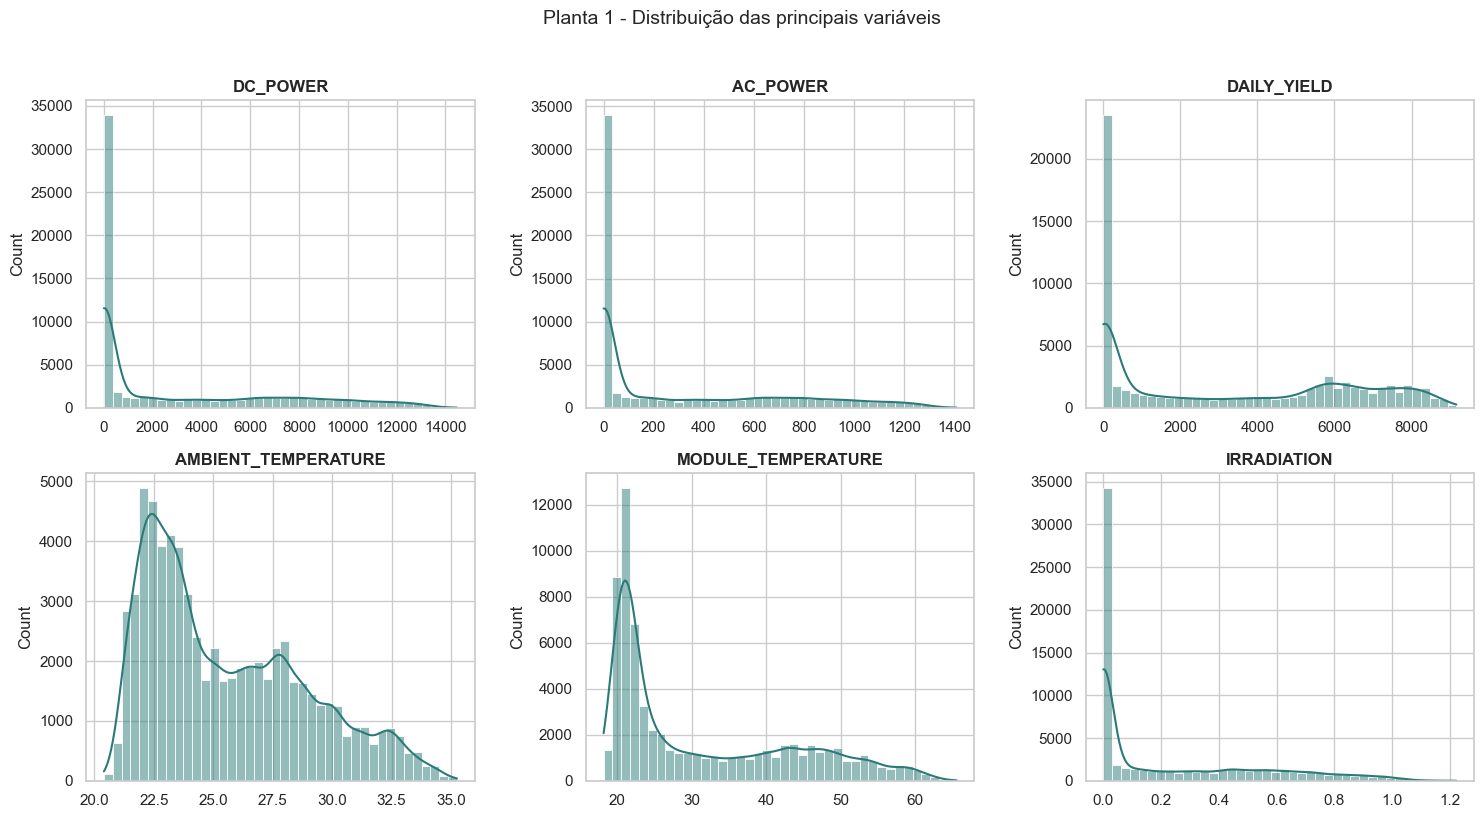

In [42]:
features_1 = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
for ax, col in zip(axes.ravel(), features_1):
    sns.histplot(df1[col].dropna(), bins = 40, kde = True, ax = ax, color = '#2b7a78')
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Planta 1 - Distribuição das principais variáveis', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()


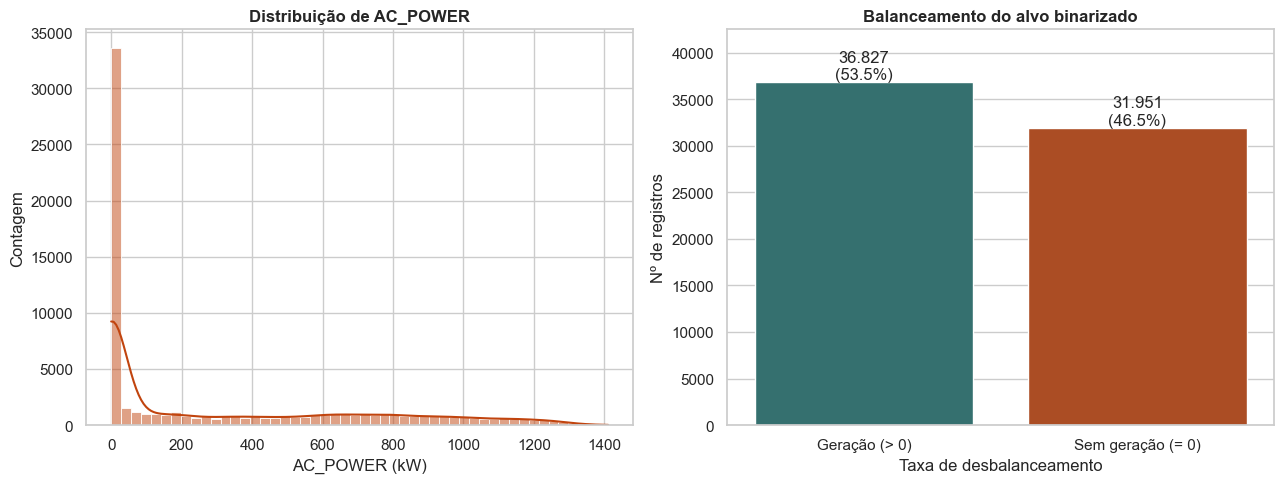

Taxa de desbalanceamento (Planta 1): {'Geração (> 0)': 53.5447, 'Sem geração (= 0)': 46.4553}
Razão entre classe majoritária/minoritária: 1.153 : 1


In [43]:
# Distribuição do alvo AC_POWER e taxa de desbalanceamento
# Alvo contínuo com forte concentração em zero (períodos noturnos sem irradiação)
# Avaliação do desbalanceamento: binarizando a Geração AC_POWER > 0 e sem geração AC_POWER == 0

fig, axes = plt.subplots(1, 2, figsize = (13, 5))
sns.histplot(df1[TARGET], bins = 50, kde = True, ax = axes[0], color = '#c1440e')
axes[0].set_title('Distribuição de AC_POWER')
axes[0].set_ylabel('Contagem')
axes[0].set_xlabel('AC_POWER (kW)')

classe_1 = np.where(df1[TARGET] > 0, 'Geração (> 0)', 'Sem geração (= 0)')
contagem_1 = pd.Series(classe_1).value_counts()
taxa_desbal_1 = contagem_1 / contagem_1.sum() * 100

pct_sem_geracao_1 = float((df1[TARGET] == 0).mean() * 100)
pct_com_geracao_1 = 100 - pct_sem_geracao_1

sns.barplot(x = contagem_1.index, y = contagem_1.values, hue = contagem_1.index, ax = axes[1],
            palette=['#2b7a78', '#c1440e'], legend = False)
axes[1].set_title('Balanceamento do alvo binarizado')
axes[1].set_ylabel('Nº de registros')
axes[1].set_xlabel('Taxa de desbalanceamento')
for i, v in enumerate(contagem_1.values):
    axes[1].text(i, v, f"{v:,}\n({taxa_desbal_1.values[i]:.1f}%)".replace(',', '.'), ha = 'center', va = 'bottom')

plt.ylim(0, 42500)
plt.tight_layout()
plt.show()

print(f"Taxa de desbalanceamento (Planta 1): {taxa_desbal_1.round(4).to_dict()}")
razao_1 = contagem_1.max() / contagem_1.min()
print(f"Razão entre classe majoritária/minoritária: {razao_1:.3f} : 1")


2.4 Relações entre variáveis:

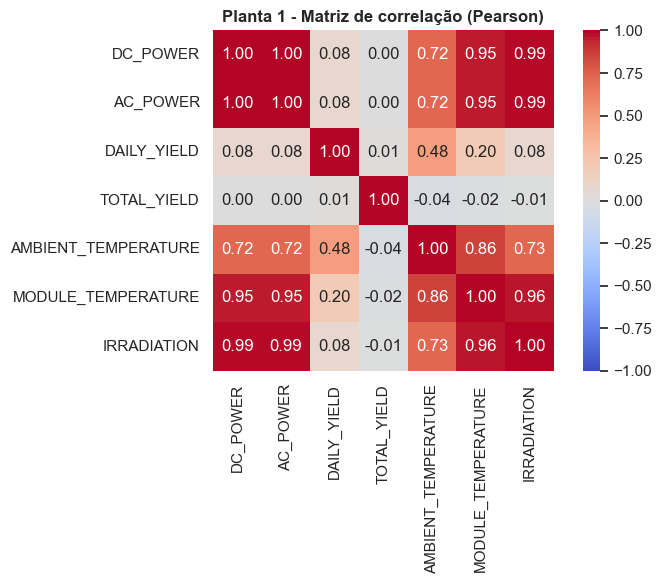

In [44]:
cols_num_1 = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
              'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
corr_1 = df1[cols_num_1].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_1, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1, square = True)
plt.title('Planta 1 - Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()


In [45]:
top5_corr_1 = corr_1[TARGET].drop(TARGET).abs().sort_values(ascending = False).head(10)
top5_corr_1_tab = pd.DataFrame({
    'variável': top5_corr_1.index,
    'correlação_com_AC_POWER': corr_1[TARGET].loc[top5_corr_1.index].values,
    '|correlação|': top5_corr_1.values,
}).reset_index(drop = True)
top5_corr_1_tab


,variável,correlação_com_AC_POWER,|correlação|
0,DC_POWER,0.999996,0.999996
1,IRRADIATION,0.989336,0.989336
2,MODULE_TEMPERATURE,0.954924,0.954924
3,AMBIENT_TEMPERATURE,0.724913,0.724913
4,DAILY_YIELD,0.082234,0.082234
5,TOTAL_YIELD,0.003804,0.003804


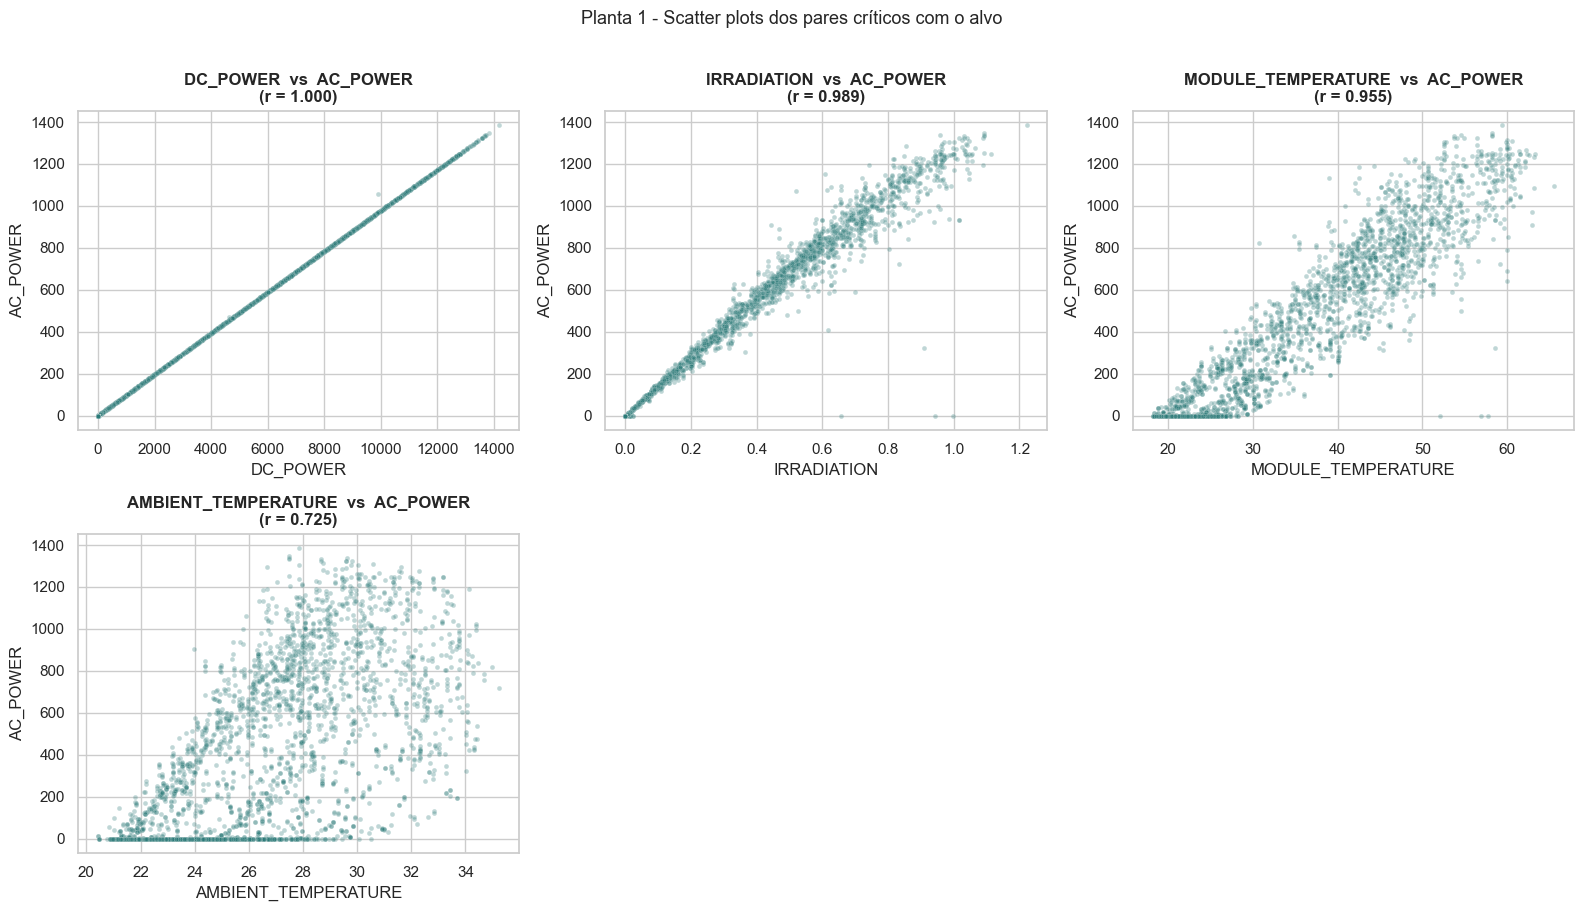

In [46]:
# Scatter plots dos pares mais críticos com maiores correlações com o alvo
N_PARES_CRITICOS = 4
pares_criticos_1 = list(top5_corr_1_tab['variável'].head(N_PARES_CRITICOS))
amostra_1 = df1.sample(min(4000, len(df1)), random_state = RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize = (16, 9))
axes = axes.ravel()
for ax, col in zip(axes, pares_criticos_1):
    sns.scatterplot(data = amostra_1, x = col, y = TARGET, alpha = 0.3, s = 12, ax = ax, color = '#2b7a78')
    ax.set_title(f'{col}  vs  {TARGET}\n(r = {corr_1.loc[col, TARGET]:.3f})')
for ax in axes[len(pares_criticos_1):]:
    ax.axis('off')
fig.suptitle('Planta 1 - Scatter plots dos pares críticos com o alvo', y = 1.01, fontsize = 13)
plt.tight_layout()
plt.show()


**3. Planta 2:**

3.1 Contexto: 

Arquivos utilizados: `Plant_2_Generation_Data.csv` (dados de geração por inversor, granularidade de 15 min) e `Plant_2_Weather_Sensor_Data.csv` (dados do sensor meteorológico da Planta 2).

Data de acesso: 02/07/2026

Período coberto: 15/05/2020 a 17/06/2020 (aproximadamente 34 dias)

In [47]:
# Carregamento dos dados da Planta 2
gen2 = pd.read_csv('Plant_2_Generation_Data.csv')
wth2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
wth2['DATE_TIME'] = pd.to_datetime(wth2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

resumo_contexto(gen2, 'Plant_2_Generation_Data.csv')
resumo_contexto(wth2, 'Plant_2_Weather_Sensor_Data.csv')

print(f"Nº de inversores (SOURCE_KEY) na Planta 2: {gen2['SOURCE_KEY'].nunique()}")


--- Plant_2_Generation_Data.csv ---
Nº de registros : 67.698
Nº de variáveis : 7
Variáveis       : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
Período         : 2020-05-15 00:00:00 até 2020-06-17 23:45:00

--- Plant_2_Weather_Sensor_Data.csv ---
Nº de registros : 3.259
Nº de variáveis : 6
Variáveis       : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
Período         : 2020-05-15 00:00:00 até 2020-06-17 23:45:00

Nº de inversores (SOURCE_KEY) na Planta 2: 22


In [48]:
df2 = pd.merge(gen2, wth2.drop(columns = ['SOURCE_KEY']), on = ['DATE_TIME', 'PLANT_ID'], how = 'left')
print(f"Base combinada Planta 2: {df2.shape[0]:,} registros x {df2.shape[1]} colunas".replace(',', '.'))
df2.head()


Base combinada Planta 2: 67.698 registros x 10 colunas


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06,27.004764,25.060789,0.0
1,2020-05-15,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09,27.004764,25.060789,0.0
2,2020-05-15,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09,27.004764,25.060789,0.0
3,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,27.004764,25.060789,0.0
4,2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07,27.004764,25.060789,0.0


3.1.1 Estatísticas descritivas da base combinada da Planta 2: 

In [49]:
desc2 = df2.describe().T
desc2


,count,mean,min,25%,50%,75%,max,std
DATE_TIME,67698,2020-06-01 10:44:33.650625024,2020-05-15 00:00:00,2020-05-23 21:00:00,2020-06-01 23:00:00,2020-06-09 23:30:00,2020-06-17 23:45:00,NaN
PLANT_ID,67698.0,4136001.0,4136001.0,4136001.0,4136001.0,4136001.0,4136001.0,0.0
DC_POWER,67698.0,246.701961,0.0,0.0,0.0,446.591667,1420.933333,370.569597
AC_POWER,67698.0,241.277825,0.0,0.0,0.0,438.215,1385.42,362.112118
DAILY_YIELD,67698.0,3294.890295,0.0,272.75,2911.0,5534.0,9873.0,2919.448386
TOTAL_YIELD,67698.0,658944788.423766,0.0,19964944.866667,282627587.0,1348495113.0,2247916295.0,729667771.073241
AMBIENT_TEMPERATURE,67698.0,27.986756,20.942385,24.570349,26.910352,30.912601,39.181638,4.021294
MODULE_TEMPERATURE,67698.0,32.607233,20.265123,23.685627,27.433723,40.019036,66.635953,11.226446
IRRADIATION,67698.0,0.229204,0.0,0.0,0.018554,0.431027,1.098766,0.309365


3.2 Qualidade dos dados: 

In [50]:
tab_ausentes_2 = pd.concat([
    resumo_ausentes(gen2, 'Plant_2_Generation_Data'),
    resumo_ausentes(wth2, 'Plant_2_Weather_Sensor_Data'),
    resumo_ausentes(df2,  'Plant_2_Combinado (merge)'),
], ignore_index = True)
tab_ausentes_2


,dataset,coluna,n_ausentes,taxa_%,decisão
0,Plant_2_Generation_Data,DATE_TIME,0,0.0,Manter (sem ausentes)
1,Plant_2_Generation_Data,PLANT_ID,0,0.0,Manter (sem ausentes)
2,Plant_2_Generation_Data,SOURCE_KEY,0,0.0,Manter (sem ausentes)
3,Plant_2_Generation_Data,DC_POWER,0,0.0,Manter (sem ausentes)
4,Plant_2_Generation_Data,AC_POWER,0,0.0,Manter (sem ausentes)
5,Plant_2_Generation_Data,DAILY_YIELD,0,0.0,Manter (sem ausentes)
6,Plant_2_Generation_Data,TOTAL_YIELD,0,0.0,Manter (sem ausentes)
7,Plant_2_Weather_Sensor_Data,DATE_TIME,0,0.0,Manter (sem ausentes)
8,Plant_2_Weather_Sensor_Data,PLANT_ID,0,0.0,Manter (sem ausentes)
9,Plant_2_Weather_Sensor_Data,SOURCE_KEY,0,0.0,Manter (sem ausentes)


In [51]:
dup_gen2_antes = gen2.duplicated().sum()
dup_wth2_antes = wth2.duplicated().sum()

gen2_dedup = gen2.drop_duplicates()
wth2_dedup = wth2.drop_duplicates()

dup_gen2_depois = gen2_dedup.duplicated().sum()
dup_wth2_depois = wth2_dedup.duplicated().sum()

dup_logica_gen2 = gen2.duplicated(subset=['DATE_TIME', 'SOURCE_KEY']).sum()

tab_dup_2 = pd.DataFrame({
    'dataset': ['Plant_2_Generation_Data', 'Plant_2_Weather_Sensor_Data'],
    'duplicatas_antes': [dup_gen2_antes, dup_wth2_antes],
    'duplicatas_depois': [dup_gen2_depois, dup_wth2_depois],
    'duplicatas_logicas_(DATE_TIME+SOURCE_KEY)': [dup_logica_gen2, np.nan],
})
tab_dup_2


,dataset,duplicatas_antes,duplicatas_depois,duplicatas_logicas_(DATE_TIME+SOURCE_KEY)
0,Plant_2_Generation_Data,0,0,0.0
1,Plant_2_Weather_Sensor_Data,0,0,NaN


In [52]:
print("Avaliação da qualidade da Planta 2:")
print(f" - Ausentes nos arquivos originais: 0 em todas as colunas -> manter, sem necessidade de imputação.")
if tab_ausentes_2.query("dataset == 'Plant_2_Combinado (merge)'")['n_ausentes'].sum() == 0:
    print(" - Após o merge geração + clima: nenhum ausente introduzido -> base combinada íntegra.")
else:
    print(" - Após o merge geração + clima: há ausentes -> avaliar imputação por interpolação temporal.")
print(f" - Duplicatas exatas: {dup_gen2_antes} (geração) e {dup_wth2_antes} (clima) -> nenhuma remoção necessária.")


Avaliação da qualidade da Planta 2:
 - Ausentes nos arquivos originais: 0 em todas as colunas -> manter, sem necessidade de imputação.
 - Após o merge geração + clima: nenhum ausente introduzido -> base combinada íntegra.
 - Duplicatas exatas: 0 (geração) e 0 (clima) -> nenhuma remoção necessária.


Implementação da imputação por interpolação temporal na base combinada da Planta 2: interpolação linear ordenada pelo tempo, usando os pontos vizinhos:

In [53]:
cols_clima_2 = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
n_ausentes_antes_2 = df2[cols_clima_2].isna().sum().sum()

if n_ausentes_antes_2 > 0:
    df2 = df2.sort_values('DATE_TIME')
    df2[cols_clima_2] = df2[cols_clima_2].interpolate(method = 'linear', limit_direction = 'both')

n_ausentes_depois_2 = df2[cols_clima_2].isna().sum().sum()
print(f"Ausentes nas colunas climáticas antes da imputação : {n_ausentes_antes_2}")
print(f"Ausentes nas colunas climáticas depois da imputação: {n_ausentes_depois_2}")


Ausentes nas colunas climáticas antes da imputação : 0
Ausentes nas colunas climáticas depois da imputação: 0


3.3 Distribuições: 

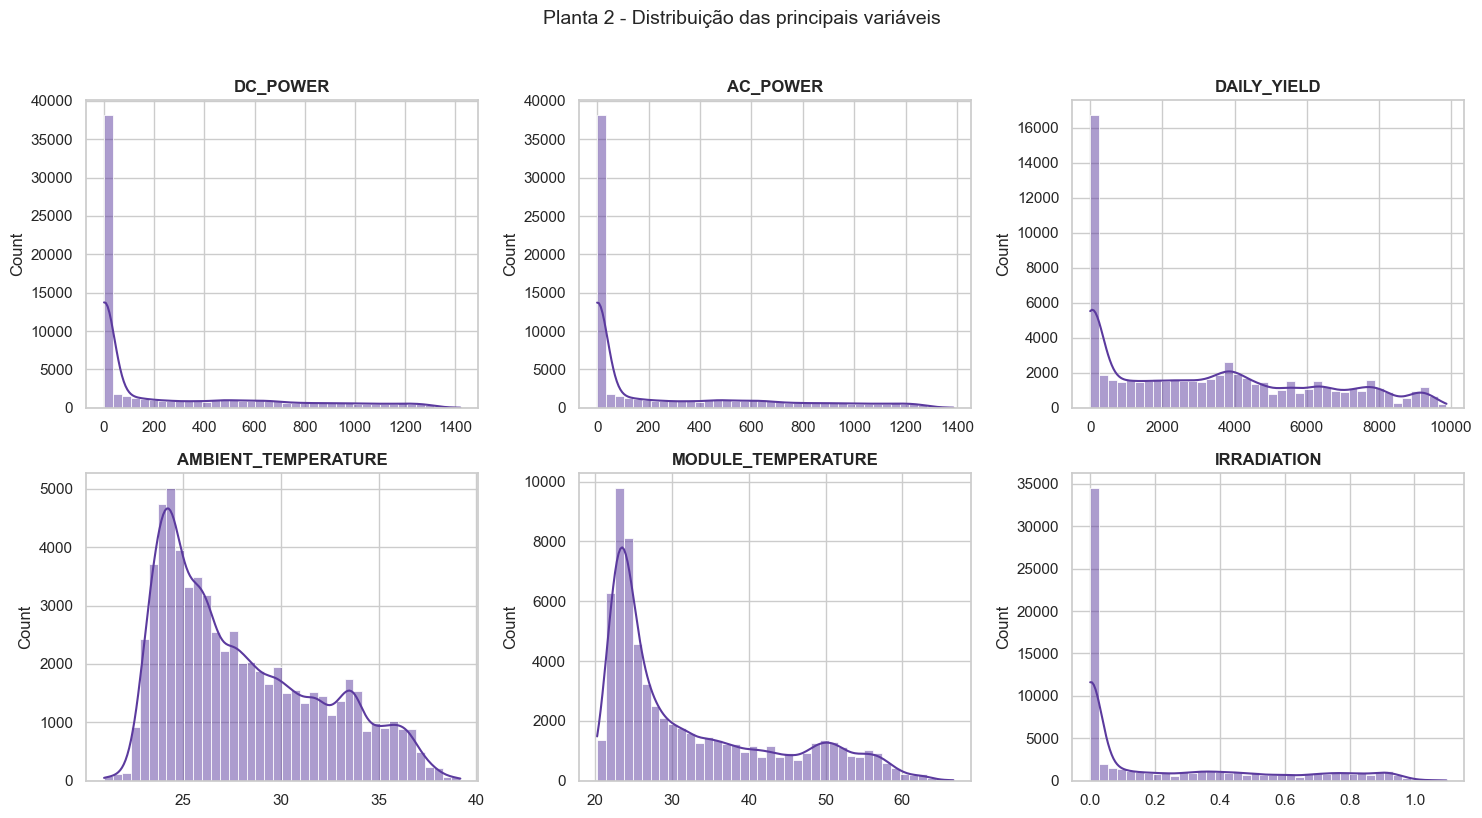

In [54]:
features_2 = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
for ax, col in zip(axes.ravel(), features_2):
    sns.histplot(df2[col].dropna(), bins = 40, kde = True, ax = ax, color = '#5b3a9e')
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle('Planta 2 - Distribuição das principais variáveis', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()


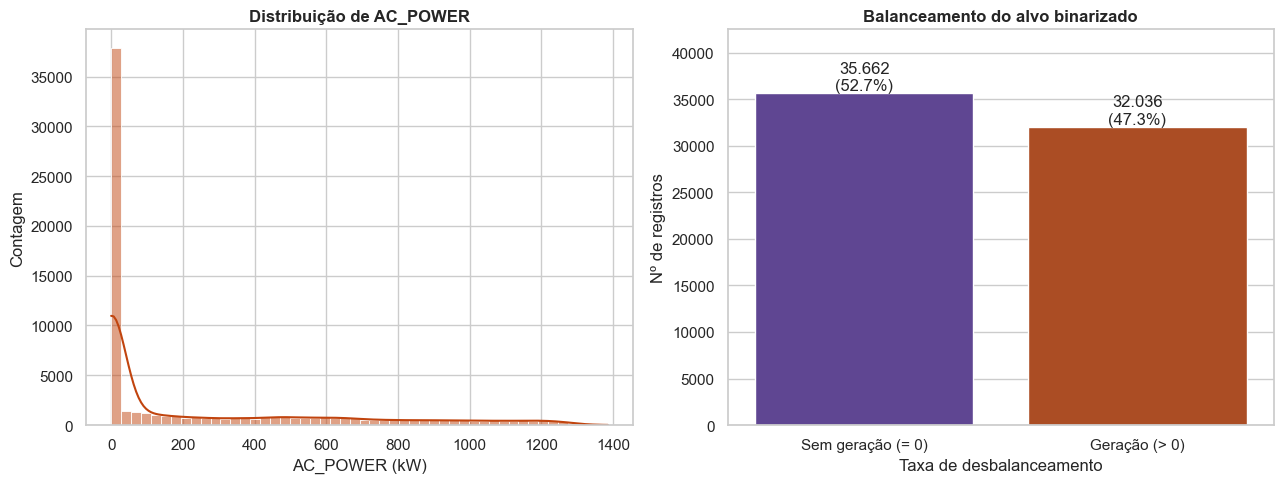

Taxa de desbalanceamento (Planta 2): {'Sem geração (= 0)': 52.6781, 'Geração (> 0)': 47.3219}
Razão entre classe majoritária/minoritária: 1.113 : 1


In [55]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5))
sns.histplot(df2[TARGET], bins = 50, kde = True, ax = axes[0], color = '#c1440e')
axes[0].set_title('Distribuição de AC_POWER')
axes[0].set_ylabel('Contagem')
axes[0].set_xlabel('AC_POWER (kW)')

classe_2 = np.where(df2[TARGET] > 0, 'Geração (> 0)', 'Sem geração (= 0)')
contagem_2 = pd.Series(classe_2).value_counts()
taxa_desbal_2 = contagem_2 / contagem_2.sum() * 100

pct_sem_geracao_2 = float((df2[TARGET] == 0).mean() * 100)
pct_com_geracao_2 = 100 - pct_sem_geracao_2

sns.barplot(x = contagem_2.index, y = contagem_2.values, hue = contagem_2.index, ax = axes[1],
            palette=['#5b3a9e', '#c1440e'], legend = False)
axes[1].set_title('Balanceamento do alvo binarizado')
axes[1].set_ylabel('Nº de registros')
axes[1].set_xlabel('Taxa de desbalanceamento')

for i, v in enumerate(contagem_2.values):
    axes[1].text(i, v, f"{v:,}\n({taxa_desbal_2.values[i]:.1f}%)".replace(',', '.'), ha = 'center', va = 'bottom')

plt.ylim(0, 42500)
plt.tight_layout()
plt.show()

print(f"Taxa de desbalanceamento (Planta 2): {taxa_desbal_2.round(4).to_dict()}")
razao_2 = contagem_2.max() / contagem_2.min()
print(f"Razão entre classe majoritária/minoritária: {razao_2:.3f} : 1")


3.4 Relações entre variáveis: 

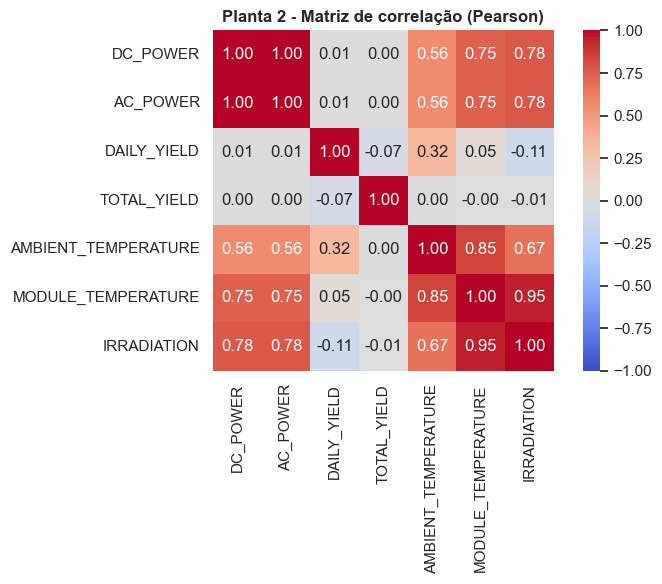

In [56]:
cols_num_2 = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD',
              'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
corr_2 = df2[cols_num_2].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(corr_2, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1, square = True)
plt.title('Planta 2 - Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()


In [57]:
top5_corr_2 = corr_2[TARGET].drop(TARGET).abs().sort_values(ascending = False).head(10)
top5_corr_2_tab = pd.DataFrame({
    'variável': top5_corr_2.index,
    'correlação_com_AC_POWER': corr_2[TARGET].loc[top5_corr_2.index].values,
    '|correlação|': top5_corr_2.values,
}).reset_index(drop = True)
top5_corr_2_tab


,variável,correlação_com_AC_POWER,|correlação|
0,DC_POWER,0.999997,0.999997
1,IRRADIATION,0.780851,0.780851
2,MODULE_TEMPERATURE,0.749604,0.749604
3,AMBIENT_TEMPERATURE,0.563324,0.563324
4,DAILY_YIELD,0.005395,0.005395
5,TOTAL_YIELD,0.004533,0.004533


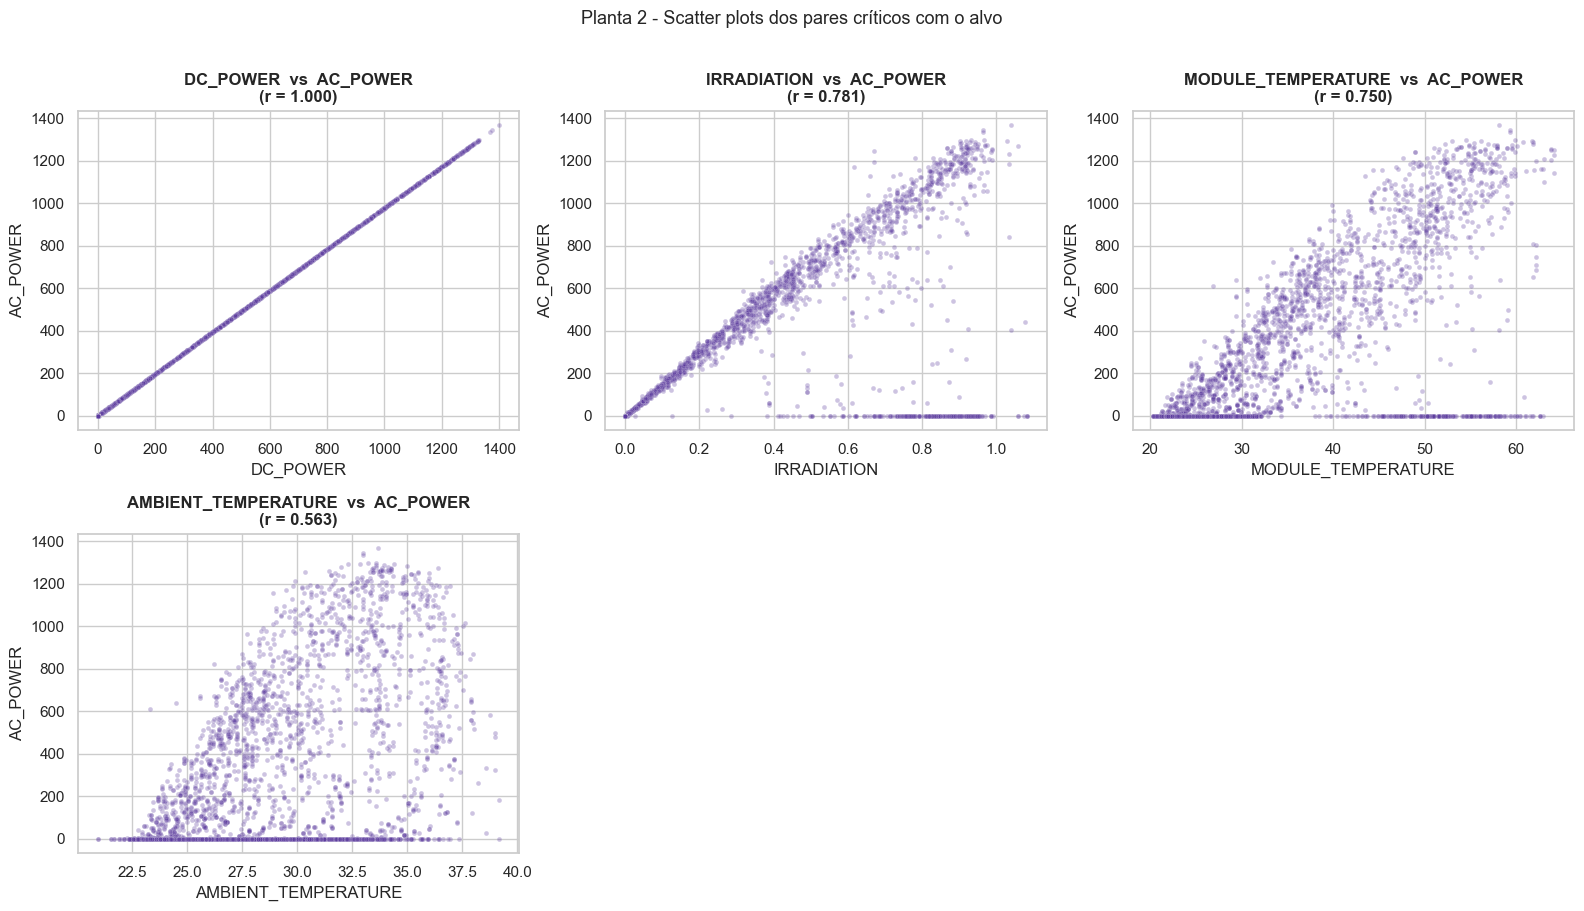

In [58]:
pares_criticos_2 = list(top5_corr_2_tab['variável'].head(N_PARES_CRITICOS))
amostra_2 = df2.sample(min(4000, len(df2)), random_state = RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize = (16, 9))
axes = axes.ravel()
for ax, col in zip(axes, pares_criticos_2):
    sns.scatterplot(data = amostra_2, x = col, y = TARGET, alpha = 0.3, s = 12, ax = ax, color = '#5b3a9e')
    ax.set_title(f'{col}  vs  {TARGET}\n(r = {corr_2.loc[col, TARGET]:.3f})')
for ax in axes[len(pares_criticos_2):]:
    ax.axis('off')
fig.suptitle('Planta 2 - Scatter plots dos pares críticos com o alvo', y = 1.01, fontsize = 13)
plt.tight_layout()
plt.show()


**4. Comparação entre Plantas 1 e 2**

In [59]:
contexto_comp = pd.DataFrame({
    'Métrica': ['Nº de registros (geração)', 'Nº de registros (clima)', 'Nº de inversores',
                'Início do período', 'Fim do período', 'Nº de colunas (base combinada)'],
    'Planta 1': [len(gen1), len(wth1), gen1['SOURCE_KEY'].nunique(),
                 str(df1['DATE_TIME'].min()), str(df1['DATE_TIME'].max()), df1.shape[1]],
    'Planta 2': [len(gen2), len(wth2), gen2['SOURCE_KEY'].nunique(),
                 str(df2['DATE_TIME'].min()), str(df2['DATE_TIME'].max()), df2.shape[1]],
})
contexto_comp


,Métrica,Planta 1,Planta 2
0,Nº de registros (geração),68778,67698
1,Nº de registros (clima),3182,3259
2,Nº de inversores,22,22
3,Início do período,2020-05-15 00:00:00,2020-05-15 00:00:00
4,Fim do período,2020-06-17 23:45:00,2020-06-17 23:45:00
5,Nº de colunas (base combinada),10,10


4.1 Estatísticas descritivas comparadas: 

In [60]:
desc_comp = pd.concat(
    {'Planta 1': desc1, 'Planta 2': desc2},
    axis = 1
)
desc_comp


Planta 1                                                                           \
                       count                           mean                  min                  25%   
DATE_TIME              68778  2020-06-01 08:02:49.458256896  2020-05-15 00:00:00  2020-05-24 00:45:00   
PLANT_ID             68778.0                      4135001.0            4135001.0            4135001.0   
DC_POWER             68778.0                    3147.426211                  0.0                  0.0   
AC_POWER             68778.0                     307.802752                  0.0                  0.0   
DAILY_YIELD          68778.0                    3295.968737                  0.0                  0.0   
TOTAL_YIELD          68778.0                 6978711.760671            6183645.0        6512002.53575   
AMBIENT_TEMPERATURE  68774.0                      25.558521            20.398505            22.724491   
MODULE_TEMPERATURE   68774.0                      31.244997            18.140415            21.123944   
IRRADIATION          68774.0                       0.232305                  0.0                  0.0   

                                                                                                  Planta 2  \
                                     50%                  75%                  max            std    count   
DATE_TIME            2020-06-01 14:30:00  2020-06-09 20:00:00  2020-06-17 23:45:00            NaN    67698   
PLANT_ID                       4135001.0            4135001.0            4135001.0            0.0  67698.0   
DC_POWER                           429.0          6366.964286            14471.125    4036.457169  67698.0   
AC_POWER                        41.49375            623.61875              1410.95     394.396439  67698.0   
DAILY_YIELD                  2658.714286               6274.0               9163.0    3145.178309  67698.0   
TOTAL_YIELD                    7146685.0        7268705.90625            7846821.0  416271.982856  67698.0   
AMBIENT_TEMPERATURE            24.670178            27.960429            35.252486         3.3613  67698.0   
MODULE_TEMPERATURE             24.818984            41.693659            65.545714      12.308283  67698.0   
IRRADIATION                      0.03162              0.45488             1.221652       0.301948  67698.0   

                                                                                                                   \
                                              mean                  min                  25%                  50%   
DATE_TIME            2020-06-01 10:44:33.650625024  2020-05-15 00:00:00  2020-05-23 21:00:00  2020-06-01 23:00:00   
PLANT_ID                                 4136001.0            4136001.0            4136001.0            4136001.0   
DC_POWER                                246.701961                  0.0                  0.0                  0.0   
AC_POWER                                241.277825                  0.0                  0.0                  0.0   
DAILY_YIELD                            3294.890295                  0.0               272.75               2911.0   
TOTAL_YIELD                       658944788.423766                  0.0      19964944.866667          282627587.0   
AMBIENT_TEMPERATURE                      27.986756            20.942385            24.570349            26.910352   
MODULE_TEMPERATURE                       32.607233            20.265123            23.685627            27.433723   
IRRADIATION                               0.229204                  0.0                  0.0             0.018554   

                                                                                 
                                     75%                  max               std  
DATE_TIME            2020-06-09 23:30:00  2020-06-17 23:45:00               NaN  
PLANT_ID                       4136001.0            4136001.0               0.0  
DC_POWER                      446.591

4.2 Qualidade comparada (ausentes e duplicatas): 

In [61]:
qualidade_comp = pd.DataFrame({
    'Métrica': ['Ausentes totais (geração)', 'Ausentes totais (clima)',
                'Duplicatas exatas (geração)', 'Duplicatas exatas (clima)',
                'Ausentes após merge geração + clima'],
    'Planta 1': [gen1.isna().sum().sum(), wth1.isna().sum().sum(),
                 dup_gen1_antes, dup_wth1_antes, df1.isna().sum().sum()],
    'Planta 2': [gen2.isna().sum().sum(), wth2.isna().sum().sum(),
                 dup_gen2_antes, dup_wth2_antes, df2.isna().sum().sum()],
})
qualidade_comp


,Métrica,Planta 1,Planta 2
0,Ausentes totais (geração),0,0
1,Ausentes totais (clima),0,0
2,Duplicatas exatas (geração),0,0
3,Duplicatas exatas (clima),0,0
4,Ausentes após merge geração + clima,0,0


4.3 Distribuições comparadas: 

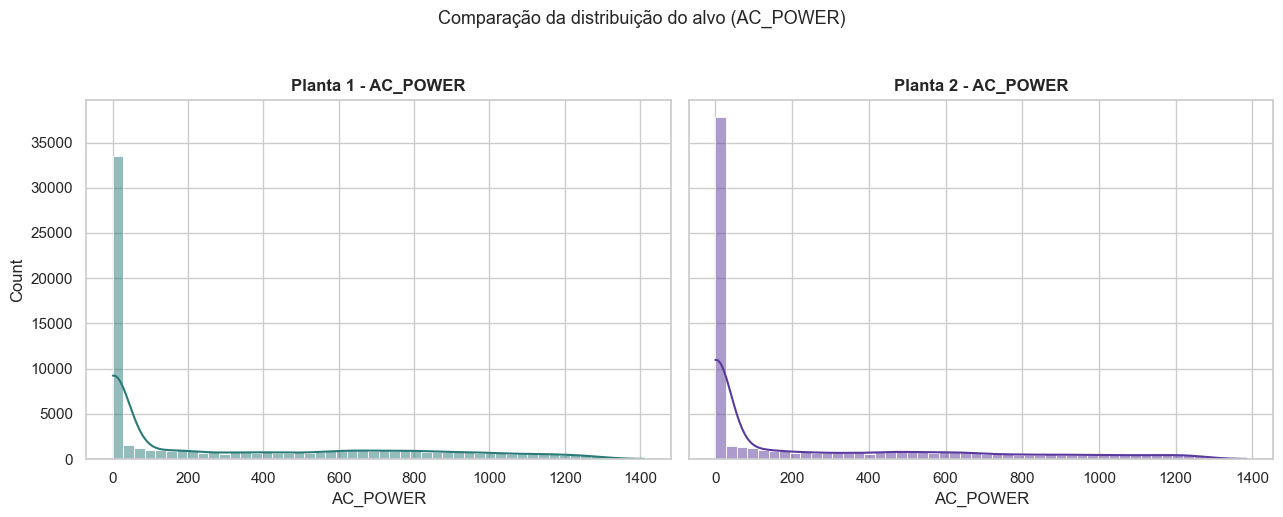

,Planta,% Sem geração (= 0),% Geração (> 0),Razão majoritário e minoritário
0,Planta 1,46.455,53.545,1.153
1,Planta 2,52.678,47.322,1.113


In [62]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5), sharey = True)
sns.histplot(df1[TARGET], bins = 50, kde = True, ax = axes[0], color = '#2b7a78')
axes[0].set_title('Planta 1 - AC_POWER')
sns.histplot(df2[TARGET], bins = 50, kde = True, ax = axes[1], color = '#5b3a9e')
axes[1].set_title('Planta 2 - AC_POWER')
fig.suptitle('Comparação da distribuição do alvo (AC_POWER)', y = 1.03, fontsize = 13)
plt.tight_layout()
plt.show()

balanc_comp = pd.DataFrame({
    'Planta': ['Planta 1', 'Planta 2'],
    '% Sem geração (= 0)': [pct_sem_geracao_1, pct_sem_geracao_2],
    '% Geração (> 0)': [pct_com_geracao_1, pct_com_geracao_2],
    'Razão majoritário e minoritário': [razao_1, razao_2],
}).round(3)
balanc_comp


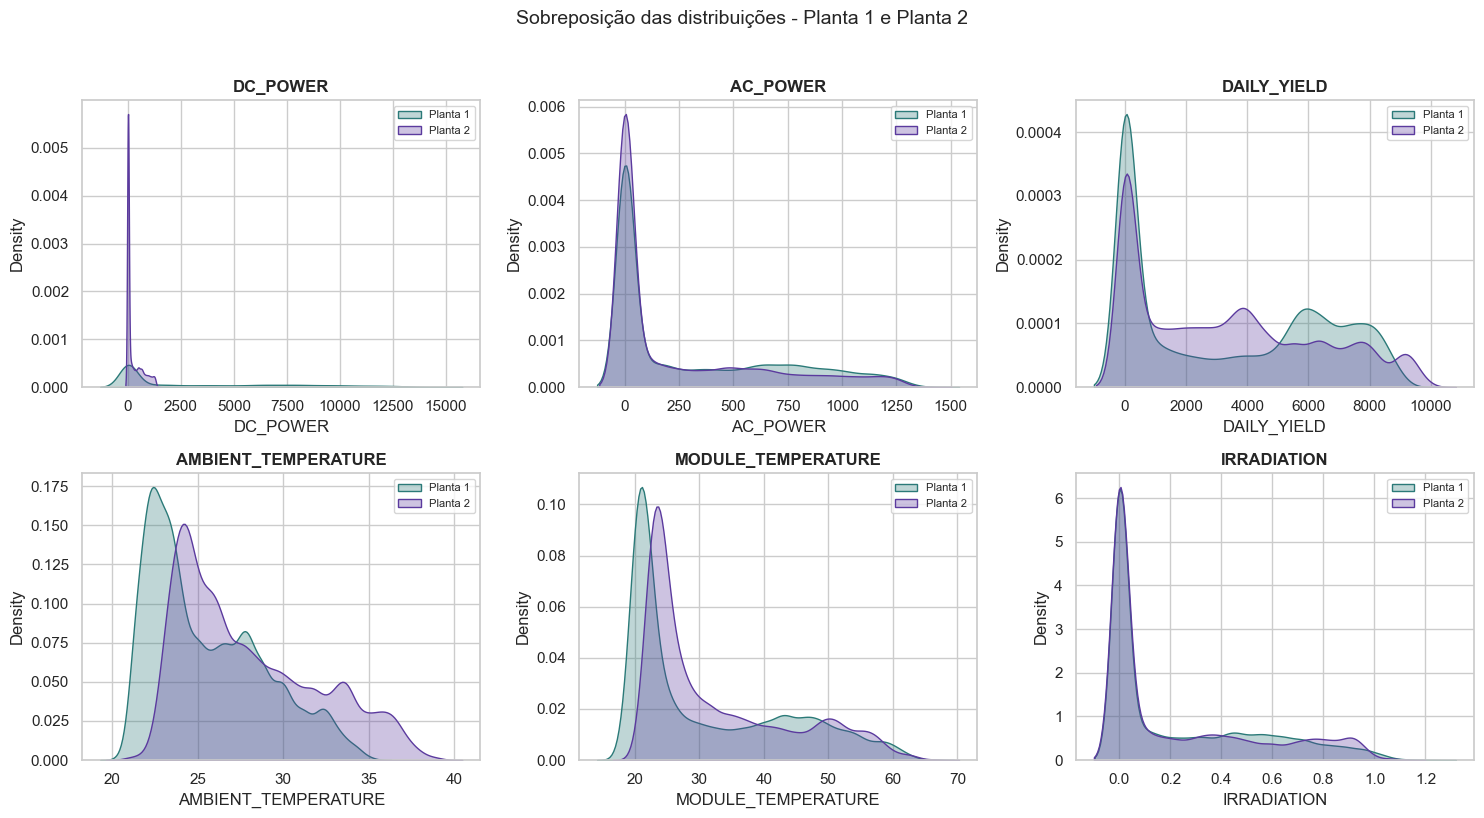

In [63]:
fig, axes = plt.subplots(2, 3, figsize = (15, 8), sharex = False)
feats_cmp = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
for ax, col in zip(axes.ravel(), feats_cmp):
    sns.kdeplot(df1[col].dropna(), ax = ax, color = '#2b7a78', label = 'Planta 1', fill = True, alpha = 0.3)
    sns.kdeplot(df2[col].dropna(), ax = ax, color = '#5b3a9e', label = 'Planta 2', fill = True, alpha = 0.3)
    ax.set_title(col)
    ax.legend(fontsize = 8)
fig.suptitle('Sobreposição das distribuições - Planta 1 e Planta 2', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()


4.4 Relações comparadas: 

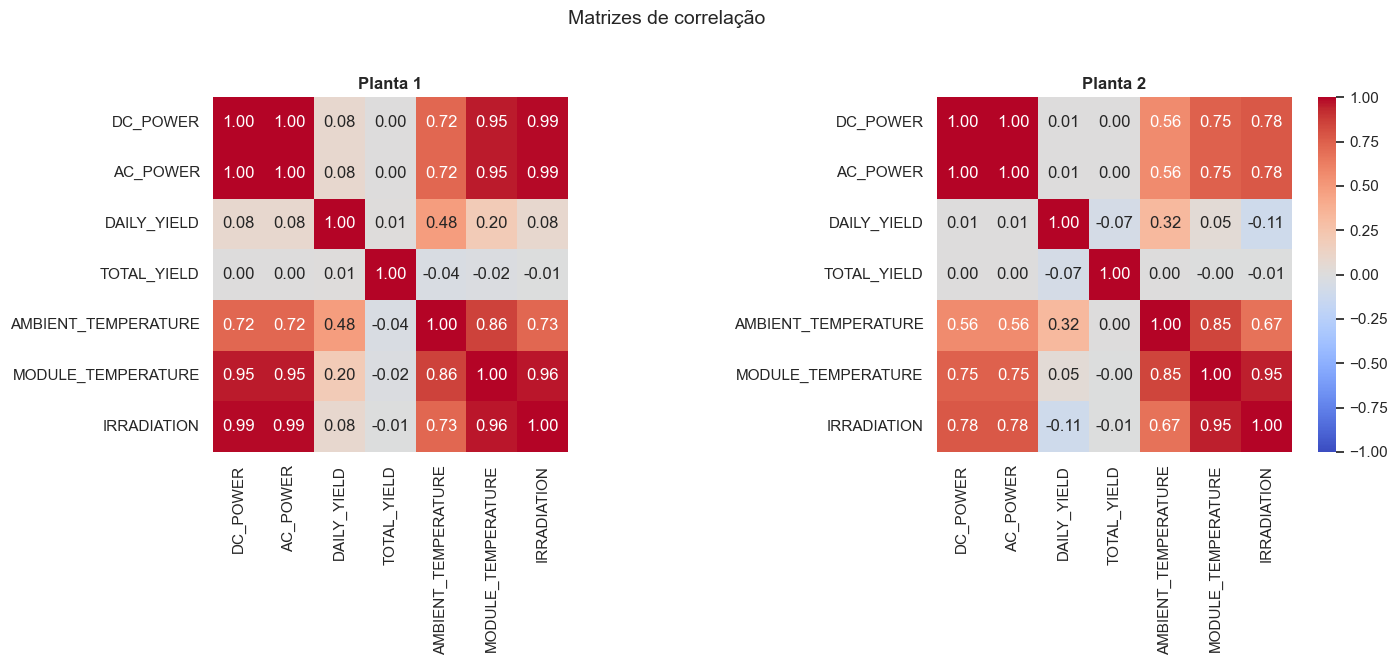

In [64]:
fig, axes = plt.subplots(1, 2, figsize = (15, 6.5))
sns.heatmap(corr_1, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1, square = True, ax = axes[0], cbar = False)
axes[0].set_title('Planta 1')
sns.heatmap(corr_2, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1, square = True, ax = axes[1])
axes[1].set_title('Planta 2')
fig.suptitle('Matrizes de correlação', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()


In [65]:
n_top = min(len(top5_corr_1_tab), len(top5_corr_2_tab))
top5_comp = pd.DataFrame({
    'Ranking': range(1, n_top + 1),
    'Planta 1 - variável': top5_corr_1_tab['variável'].values[:n_top],
    'Planta 1 - correlação': top5_corr_1_tab['correlação_com_AC_POWER'].round(3).values[:n_top],
    'Planta 2 - variável': top5_corr_2_tab['variável'].values[:n_top],
    'Planta 2 - correlação': top5_corr_2_tab['correlação_com_AC_POWER'].round(3).values[:n_top],
})
top5_comp


,Ranking,Planta 1 - variável,Planta 1 - correlação,Planta 2 - variável,Planta 2 - correlação
0,1,DC_POWER,1.000,DC_POWER,1.000
1,2,IRRADIATION,0.989,IRRADIATION,0.781
2,3,MODULE_TEMPERATURE,0.955,MODULE_TEMPERATURE,0.750
3,4,AMBIENT_TEMPERATURE,0.725,AMBIENT_TEMPERATURE,0.563
4,5,DAILY_YIELD,0.082,DAILY_YIELD,0.005
5,6,TOTAL_YIELD,0.004,TOTAL_YIELD,0.005


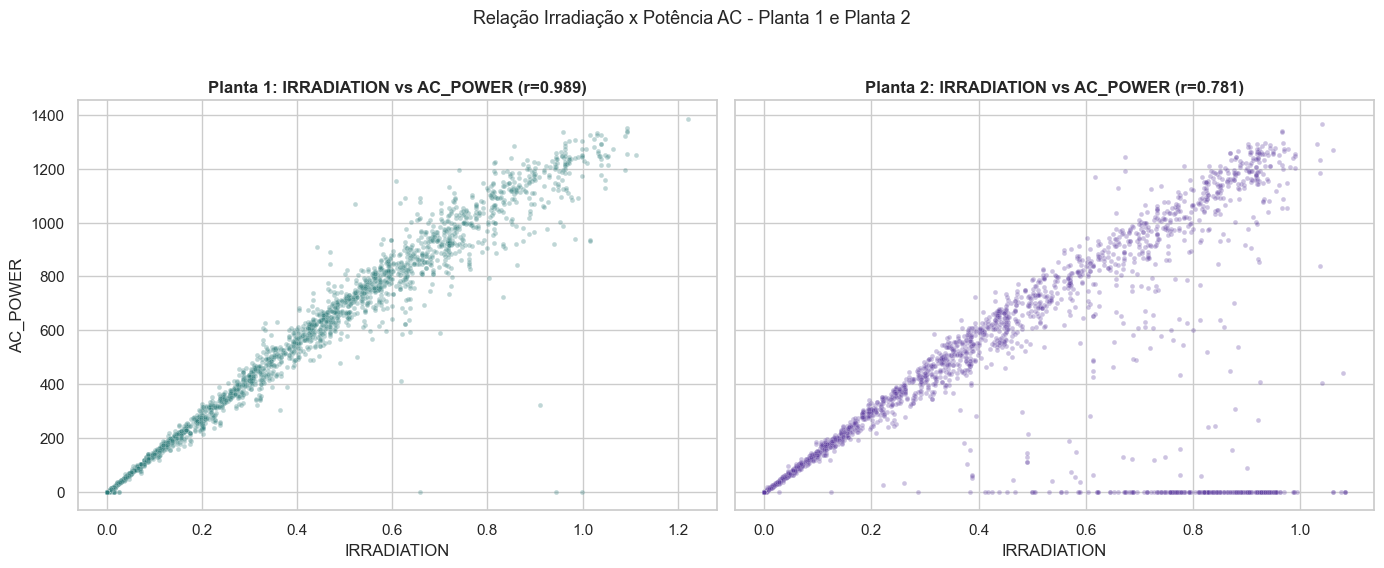

In [66]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5.5), sharey = True)
sample1 = df1.sample(min(4000, len(df1)), random_state = RANDOM_STATE)
sample2 = df2.sample(min(4000, len(df2)), random_state = RANDOM_STATE)

sns.scatterplot(data=sample1, x = 'IRRADIATION', y = TARGET, alpha = 0.3, s = 12, ax = axes[0], color = '#2b7a78')
axes[0].set_title(f"Planta 1: IRRADIATION vs AC_POWER (r={corr_1.loc['IRRADIATION', TARGET]:.3f})")

sns.scatterplot(data = sample2, x = 'IRRADIATION', y = TARGET, alpha = 0.3, s = 12, ax = axes[1], color = '#5b3a9e')
axes[1].set_title(f"Planta 2: IRRADIATION vs AC_POWER (r={corr_2.loc['IRRADIATION', TARGET]:.3f})")

fig.suptitle('Relação Irradiação x Potência AC - Planta 1 e Planta 2', fontsize = 13, y = 1.03)
plt.tight_layout()
plt.show()


4.5 Resumo da comparação: 

Ambas as plantas cobrem um período semelhante (aproximadamente de 34 dias, de maio a junho de 2020). 

Os valores ausentes foram tratados com interpolação temporal (Planta 1). 

A variável alvo `AC_POWER` é fortemente concentrad em zero em ambas as plantas, refletindo os períodos noturnos sem geração solar. 

Em ambas as plantas, `DC_POWER` e `IRRADIATION` são as variáveis mais correlacionadas com `AC_POWER`.

As distribuições de temperatura ambiente e do módulo são semelhantes entre as plantas, sugerindo condições climáticas regionais próximas, enquanto a magnitude de `DC_POWER`/`AC_POWER` pode diferir conforme a capacidade instalada de cada planta.